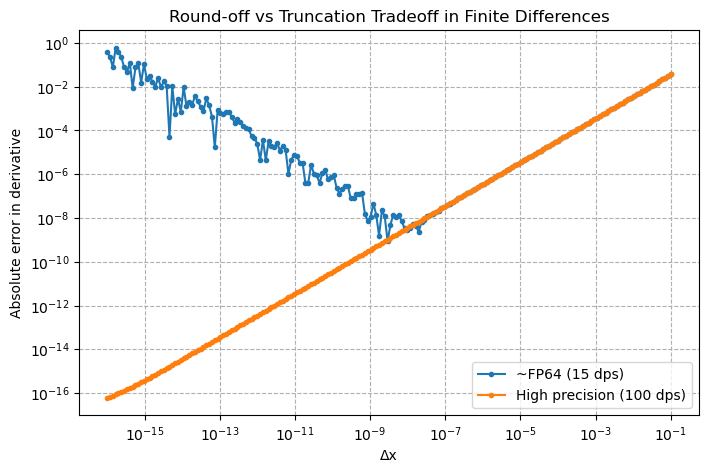

In [1]:
import mpmath as mp
import numpy as np
import matplotlib.pyplot as plt

# Define function for derivative test
def f(x):
    return mp.sin(x)

# True derivative at x0
x0 = mp.pi / 4
true_derivative = mp.cos(x0)

# Range of step sizes
deltas = [10**(-k) for k in np.linspace(1, 16, 200)]

# Compute finite difference derivative errors at two precisions
def derivative_error(precision):
    mp.mp.dps = precision
    errors = []
    for dx in deltas:
        fd = (f(x0 + dx) - f(x0)) / dx
        err = abs(fd - true_derivative)
        errors.append(err)
    return np.array(errors)

# Compute errors for 64-bit-like precision (15 dps) and high precision (100 dps)
errors_fp64 = derivative_error(15)
errors_high = derivative_error(100)

# Plot
plt.figure(figsize=(8,5))
plt.loglog(deltas, errors_fp64, label="~FP64 (15 dps)", marker='.')
plt.loglog(deltas, errors_high, label="High precision (100 dps)", marker='.')
plt.xlabel("Δx")
plt.ylabel("Absolute error in derivative")
plt.title("Round-off vs Truncation Tradeoff in Finite Differences")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


In [3]:
import time

# Number of operations
N = 1_000_000

# FP64-like precision (15 dps)
mp.mp.dps = 15
a = mp.mpf('3.141592653589793')
b = mp.mpf('2.718281828459045')

start = time.time()
for _ in range(N):
    _ = a / b
t_fp64 = time.time() - start

# High precision (100 dps)
mp.mp.dps = 100
a = mp.mpf('3.1415926535897932384626433832795028841971')
b = mp.mpf('2.7182818284590452353602874713526624977572')

start = time.time()
for _ in range(N):
    _ = a / b
t_high = time.time() - start

t_fp64, t_high, t_high / t_fp64


(0.5996670722961426, 0.688410758972168, 1.1479882601127709)

In [4]:
import time
import mpmath as mp

# We'll use 200k divisions to keep runtime reasonable for high precision.
N = 200_000

precisions = [15, 100, 500, 1000]
times = {}

for prec in precisions:
    mp.mp.dps = prec
    a = mp.mpf('3.14159265358979323846264338327950288419716939937510')
    b = mp.mpf('2.71828182845904523536028747135266249775724709369995')
    start = time.perf_counter()
    for _ in range(N):
        _ = a / b
    elapsed = time.perf_counter() - start
    times[prec] = elapsed

times



{15: 0.12637687399910646,
 100: 0.13706149999779882,
 500: 0.2559531010010687,
 1000: 0.5792880540029728}